<a href="https://colab.research.google.com/github/pragadeesh1024/healthcare-fraud-detection/blob/main/healthcare_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df=pd.read_csv('/content/healthcare_fraud_detection.csv')
df

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,P0289,C0009995,79,Male,E78.5,71046,590.19,205.00,Private,2024-09-24,2,115,Internal Medicine,PA,Approved,1,2,Inpatient,1,3.0
9996,P0248,C0009996,66,Male,K21.9,93000,219.73,191.89,Self-Pay,2023-01-04,6,73,Orthopedics,IL,Approved,0,5,Inpatient,0,6.0
9997,P0122,C0009997,43,Female,F41.9,99213,505.24,447.94,Medicare,2024-06-30,6,59,Neurology,OH,Rejected,0,5,Emergency,1,0.0
9998,P0072,C0009998,39,Female,I10,93000,564.25,507.18,Medicare,2022-03-15,8,55,Cardiology,TX,Pending,0,5,Emergency,0,6.0


In [37]:
df.isnull().sum()

,0
Provider_ID,0
Claim_ID,0
Patient_Age,0
Patient_Gender,0
Diagnosis_Code,0
Procedure_Code,0
Claim_Amount,0
Approved_Amount,0
Insurance_Type,350
Claim_Submission_Date,0


In [38]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])

In [39]:
df

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,52,0,37,1,4,36415,443.51,393.16,0,1330,13,70,0,4,0,0,0,2,1,2.0
1,121,1,21,0,0,99213,467.50,461.33,3,606,5,62,1,3,1,0,5,1,1,2.0
2,140,2,78,0,5,93000,591.69,530.06,0,459,29,60,0,3,1,0,5,1,1,3.0
3,202,3,65,1,3,93000,235.15,189.11,2,1006,22,70,1,7,0,0,0,0,0,5.0
4,135,4,36,1,8,85025,487.96,369.91,2,970,21,67,5,6,0,0,5,1,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,289,9995,79,1,1,71046,590.19,205.00,2,1353,2,115,2,6,0,1,2,1,1,3.0
9996,248,9996,66,1,7,93000,219.73,191.89,3,727,6,73,4,3,0,0,5,1,0,6.0
9997,122,9997,43,0,2,99213,505.24,447.94,1,1267,6,59,3,5,2,0,5,0,1,0.0
9998,72,9998,39,0,3,93000,564.25,507.18,1,432,8,55,0,7,1,0,5,0,0,6.0


In [40]:
from sklearn.impute import KNNImputer
knn=KNNImputer()
df['Insurance_Type']=knn.fit_transform(df[['Insurance_Type']])
df['Provider_Specialty']=knn.fit_transform(df[['Provider_Specialty']])
df['Prior_Visits_12m']=knn.fit_transform(df[['Prior_Visits_12m']])


In [41]:
df.isnull().sum()

,0
Provider_ID,0
Claim_ID,0
Patient_Age,0
Patient_Gender,0
Diagnosis_Code,0
Procedure_Code,0
Claim_Amount,0
Approved_Amount,0
Insurance_Type,0
Claim_Submission_Date,0


In [42]:
df

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,52,0,37,1,4,36415,443.51,393.16,0.0,1330,13,70,0.0,4,0,0,0,2,1,2.000000
1,121,1,21,0,0,99213,467.50,461.33,3.0,606,5,62,1.0,3,1,0,5,1,1,2.000000
2,140,2,78,0,5,93000,591.69,530.06,0.0,459,29,60,0.0,3,1,0,5,1,1,3.000000
3,202,3,65,1,3,93000,235.15,189.11,2.0,1006,22,70,1.0,7,0,0,0,0,0,5.000000
4,135,4,36,1,8,85025,487.96,369.91,2.0,970,21,67,5.0,6,0,0,5,1,0,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,289,9995,79,1,1,71046,590.19,205.00,2.0,1353,2,115,2.0,6,0,1,2,1,1,3.000000
9996,248,9996,66,1,7,93000,219.73,191.89,3.0,727,6,73,4.0,3,0,0,5,1,0,6.000000
9997,122,9997,43,0,2,99213,505.24,447.94,1.0,1267,6,59,3.0,5,2,0,5,0,1,0.000000
9998,72,9998,39,0,3,93000,564.25,507.18,1.0,432,8,55,0.0,7,1,0,5,0,0,6.000000


In [43]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Patient_Age']=sc.fit_transform(df[['Patient_Age']])
df['Procedure_Code']=sc.fit_transform(df[['Procedure_Code']])
df['Claim_Amount']=sc.fit_transform(df[['Claim_Amount']])
df['Approved_Amount']=sc.fit_transform(df[['Approved_Amount']])
df['Days_Between_Service_and_Claim']=sc.fit_transform(df[['Days_Between_Service_and_Claim']])
df['Number_of_Claims_Per_Provider_Monthly']=sc.fit_transform(df[['Number_of_Claims_Per_Provider_Monthly']])
df['Is_Fraud']=sc.fit_transform(df[['Is_Fraud']])
df['Length_of_Stay']=sc.fit_transform(df[['Length_of_Stay']])
df['Chronic_Condition_Flag']=sc.fit_transform(df[['Chronic_Condition_Flag']])
df['Prior_Visits_12m']=sc.fit_transform(df[['Prior_Visits_12m']])
df

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,52,0,-0.712202,1,4,-3.373982,-0.318316,-0.254776,0.0,1330,-0.166536,0.092049,0.0,4,0,-0.300655,-1.285859,2,1.557131,-0.606532
1,121,1,-1.605595,0,0,0.822462,-0.259254,-0.043881,3.0,606,-1.108882,-0.444679,1.0,3,1,-0.300655,1.637478,1,1.557131,-0.606532
2,140,2,1.577118,0,5,0.407281,0.046495,0.168747,0.0,459,1.718156,-0.578861,0.0,3,1,-0.300655,1.637478,1,1.557131,-0.015615
3,202,3,0.851236,1,3,0.407281,-0.831288,-0.886039,2.0,1006,0.893603,0.092049,1.0,7,0,-0.300655,-1.285859,0,-0.642207,1.166220
4,135,4,-0.768039,1,8,-0.125644,-0.208883,-0.326704,2.0,970,0.775810,-0.109224,5.0,6,0,-0.300655,1.637478,1,-0.642207,0.575302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,289,9995,1.632955,1,1,-1.059784,0.042802,-0.836881,2.0,1353,-1.462262,3.111144,2.0,6,0,3.326068,-0.116524,1,1.557131,-0.015615
9996,248,9996,0.907073,1,7,0.407281,-0.869251,-0.877439,3.0,727,-0.991089,0.293322,4.0,3,0,-0.300655,1.637478,1,-0.642207,1.757137
9997,122,9997,-0.377179,0,2,0.822462,-0.166340,-0.085305,1.0,1267,-0.991089,-0.645952,3.0,5,2,-0.300655,1.637478,0,1.557131,-1.788367
9998,72,9998,-0.600528,0,3,0.407281,-0.021061,0.097964,1.0,432,-0.755502,-0.914316,0.0,7,1,-0.300655,1.637478,0,-0.642207,1.757137


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [44]:
x=df.drop('Prior_Visits_12m',axis=1)

In [45]:
from sklearn.cluster import KMeans


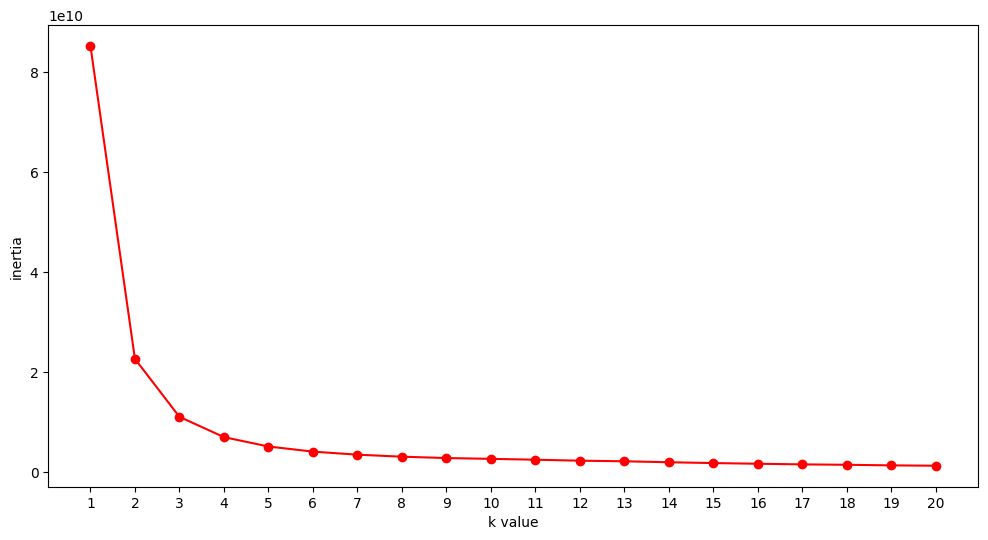

In [51]:
e=[]
for k in range(1,21):
  km=KMeans(n_clusters=k)
  km.fit(x)
  e.append(km.inertia_)

plt.figure(figsize=(12,6))
plt.plot(range(1,21),e,color='red',marker='o')
plt.xticks(range(1,21))
plt.xlabel('k value')
plt.ylabel('inertia')
plt.show()

In [55]:
km=KMeans(n_clusters=2)
kl= km.fit(x)
y_pred=km.fit_predict(x)

In [56]:
y_pred

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [57]:
from sklearn.metrics import silhouette_score
silhouette_score(x,y_pred)

np.float64(0.5991102817021119)

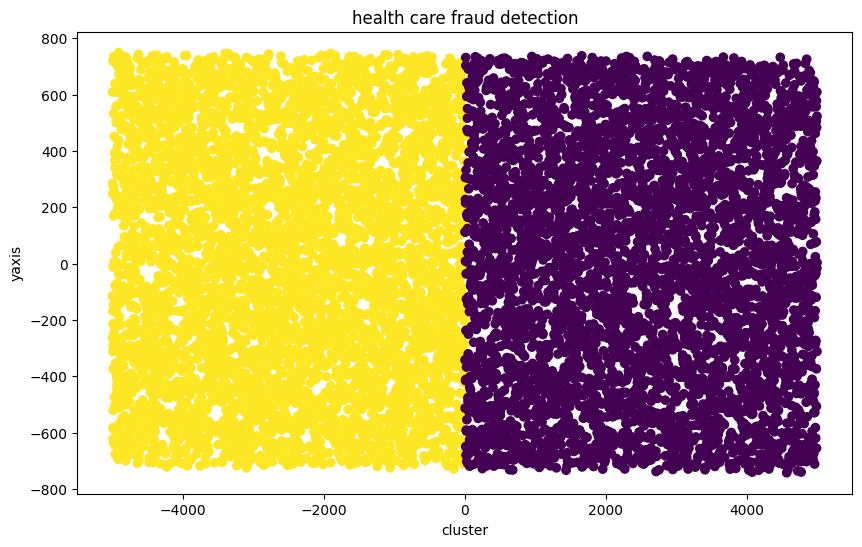

In [60]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x)
plt.figure(figsize=(10,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=y_pred)
plt.title("health care fraud detection")
plt.xlabel('cluster')
plt.ylabel('yaxis')
plt.show()